# 08 — Model 5: Transformer (top of the complexity ladder)

**Model 5** is a Transformer on the raw 96-timestep signal — the top rung:

> linear (~6) → shallow (3.9k) → medium (44k) → deep CNN (404k) → **transformer (~1.2M)**

Because single-seed proved misleading on Model 4, Model 5 is **multi-seed from the start** — 5 seeds
(0–4), same as the multi-seed CNN pass, no single-seed detour.

**Transformer vs CNN, for time-series.** A CNN detects *local* patterns with small filters sliding
along the signal; locality is built up through depth. A Transformer uses **self-attention**: every
timestep can attend *directly* to every other, relating distant positions in one step. That is more
flexible but **data-hungry** — on 80 training samples it is the model most at risk of instability, so
we watch stability and whether it even matches the CNNs.

## Architecture, patching, and the region-grid note

Encoder: **per-timestep linear embedding → learned positional encoding → 6 Transformer encoder blocks
(d_model 128, 8 heads, GELU, pre-norm) → mean-pool → linear head.** Input is `(n, 1, 96)`, identical to
the CNNs, so the shared `train_cnn` recipe and `torch_predict_proba` harness wrapper work unchanged.

**Patching / grid compatibility (the design note that matters).** We embed **per-timestep
(patch_size = 1)** → 96 tokens, one per timestep. Reason: the harness attributes onto the layer-1
RegionGrid, which groups raw timesteps into ~10 regions. Per-timestep tokens map **exactly** onto that
grid (each region = a contiguous block of tokens via `grid.labels`), so the transformer stays
grid-comparable to the CNNs — and the eventual **attention analysis** (per-token weights) pools to
regions with **no boundary misalignment**. A larger patch size would cut tokens/compute but, because 96
does not split into 10 equal patches, fixed patches would **straddle region boundaries** and muddy
attention→region pooling. We flagged that tension and chose patch_size=1 to avoid it (FeatureAblation /
KernelSHAP / IG are unaffected either way — they perturb the raw input).

**Recipe — no deviation from the CNNs.** A quick probe found the **shared CNN recipe (Adam lr 1e-3,
wd 1e-4)** trained the transformer *best* (lower LRs underperformed), so we reuse it unchanged for
cross-model consistency. The only transformer-specific regularisation is the model's built-in
**dropout 0.1** (standard). Same batch 16, 200 epochs, early stopping (patience 30), class-weighted CE,
seed-before-build per seed.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))
import json, numpy as np, torch, matplotlib.pyplot as plt
from src.models.transformer import build_transformer
from src.models.cnn import count_parameters
FIG_DIR = PROJECT_ROOT / "results" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

m = build_transformer()
print(f"Transformer params: {count_parameters(m):,}  (tokens=96 per-timestep, d_model=128, heads=8, layers=6)")
print(f"forward (2,1,96) -> {tuple(m(torch.zeros(2,1,96)).shape)}  (valid)")

# 5-seed results produced by run_transformer_seeds.py (seeds 0-4), loaded here.
R = json.load(open(PROJECT_ROOT / "results" / "metrics" / "transformer_seeds.json"))
ps = R["per_seed"]
def col(k, sub=None): return np.array([(r[k][sub] if sub else r[k]) for r in ps], dtype=float)

Transformer params: 1,202,690  (tokens=96 per-timestep, d_model=128, heads=8, layers=6)
forward (2,1,96) -> (2, 2)  (valid)


/Users/luciepasquier/Desktop/IMPERIAL/SUMMER THESIS/Thesis-Repo/src/models/transformer.py:76: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)


In [2]:
print("Per-seed (Model 5 transformer):")
print(f"{'seed':>4} {'test':>6} {'bal':>6} {'f1':>6} {'auc':>6} {'train':>6} {'val':>6} {'gap':>6} collapsed")
for r in ps:
    print(f"{r['seed']:>4} {r['test']['accuracy']:>6.3f} {r['test']['balanced_accuracy']:>6.3f} "
          f"{r['test']['f1']:>6.3f} {r['test']['roc_auc']:>6.3f} {r['train']['accuracy']:>6.3f} "
          f"{r['val']['accuracy']:>6.3f} {r['overfit_gap']:>+6.3f} {r['collapsed']}")
def ms(v): return f"{v.mean():.3f}±{v.std():.3f}"
print(f"\nAGGREGATE (mean±std): test {ms(col('test','accuracy'))}  bal {ms(col('test','balanced_accuracy'))}  "
      f"f1 {ms(col('test','f1'))}  auc {ms(col('test','roc_auc'))}")
print(f"  train {ms(col('train','accuracy'))}  val {ms(col('val','accuracy'))}  val-test gap {ms(col('overfit_gap'))}")
print(f"  collapsed {sum(r['collapsed'] for r in ps)}/5   spread test [{col('test','accuracy').min():.2f}, {col('test','accuracy').max():.2f}]")

Per-seed (Model 5 transformer):
seed   test    bal     f1    auc  train    val    gap collapsed
   0  0.830  0.819  0.866  0.904  0.838  1.000 +0.170 False
   1  0.800  0.783  0.844  0.863  0.925  0.800 +0.000 False
   2  0.750  0.738  0.800  0.842  0.887  0.850 +0.100 False
   3  0.770  0.747  0.822  0.805  0.900  0.900 +0.130 False
   4  0.740  0.718  0.797  0.831  0.900  0.900 +0.160 False

AGGREGATE (mean±std): test 0.778±0.033  bal 0.761±0.036  f1 0.826±0.026  auc 0.849±0.033
  train 0.890±0.029  val 0.890±0.066  val-test gap 0.112±0.061
  collapsed 0/5   spread test [0.74, 0.83]


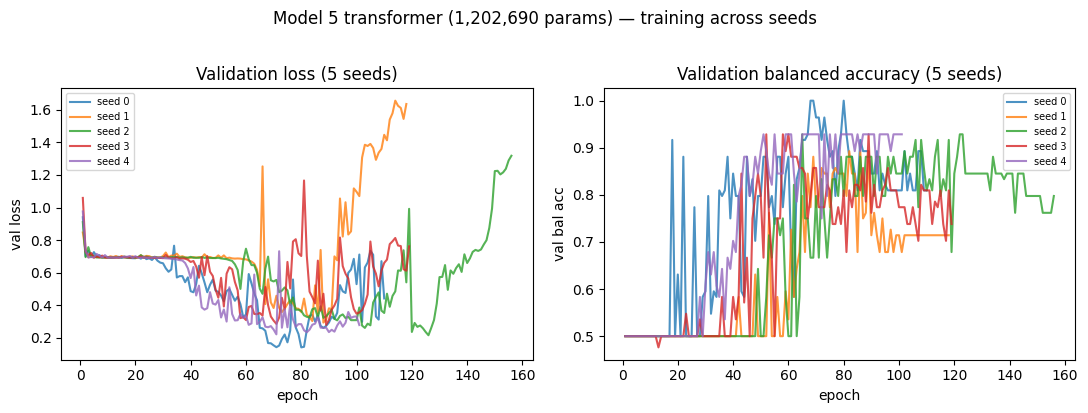

In [3]:
# Training curves across the 5 seeds (stability check)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for r in ps:
    e = np.arange(1, len(r['history']['train_loss'])+1)
    ax[0].plot(e, r['history']['val_loss'], alpha=0.8, label=f"seed {r['seed']}")
    ax[1].plot(e, r['history']['val_balanced_accuracy'], alpha=0.8, label=f"seed {r['seed']}")
ax[0].set_title("Validation loss (5 seeds)"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("val loss"); ax[0].legend(fontsize=7)
ax[1].set_title("Validation balanced accuracy (5 seeds)"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val bal acc"); ax[1].legend(fontsize=7)
fig.suptitle(f"Model 5 transformer ({count_parameters(m):,} params) — training across seeds", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "08_model5_training.png", dpi=150, bbox_inches="tight"); plt.show()

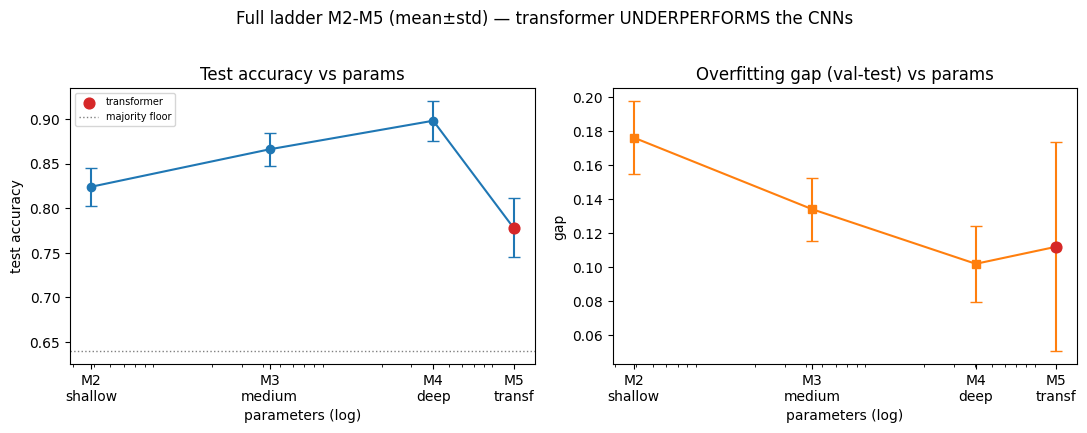

In [4]:
# Full ladder: test accuracy & overfitting gap vs params (M2-M4 CNN multiseed + M5 transformer)
C = json.load(open(PROJECT_ROOT / "results" / "metrics" / "multiseed_ladder.json"))
def cnn(a, key, sub=None):
    v=[(r[key][sub] if sub else r[key]) for r in C['arch'][a]['per_seed'] if not r['collapsed']]
    return np.mean(v), np.std(v)
px=[3858,43682,403522, R['params']]; lab=["M2\nshallow","M3\nmedium","M4\ndeep","M5\ntransf"]
acc=[cnn('shallow','test_acc'),cnn('medium','test_acc'),cnn('deep','test_acc'),(col('test','accuracy').mean(),col('test','accuracy').std())]
gap=[cnn('shallow','overfit_gap'),cnn('medium','overfit_gap'),cnn('deep','overfit_gap'),(col('overfit_gap').mean(),col('overfit_gap').std())]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].errorbar(px,[a[0] for a in acc],yerr=[a[1] for a in acc],marker='o',capsize=4,color='C0')
ax[0].scatter([px[-1]],[acc[-1][0]],color='C3',zorder=5,s=60,label='transformer')
ax[0].axhline(0.64,color='grey',ls=':',lw=1,label='majority floor'); ax[0].set_title("Test accuracy vs params"); ax[0].set_ylabel("test accuracy"); ax[0].legend(fontsize=7)
ax[1].errorbar(px,[g[0] for g in gap],yerr=[g[1] for g in gap],marker='s',capsize=4,color='C1')
ax[1].scatter([px[-1]],[gap[-1][0]],color='C3',zorder=5,s=60); ax[1].set_title("Overfitting gap (val-test) vs params"); ax[1].set_ylabel("gap")
for a in ax:
    a.set_xscale('log'); a.set_xlabel("parameters (log)"); a.set_xticks(px); a.set_xticklabels(lab)
fig.suptitle("Full ladder M2-M5 (mean±std) — transformer UNDERPERFORMS the CNNs", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "08_model5_ladder.png", dpi=150, bbox_inches="tight"); plt.show()

## Results and honest read

**Parameter count: 1,202,690** (~1.2M — the ladder's top step, as planned). **0 of 5 seeds collapsed** —
every seed learned above the ~64% majority floor.

**Aggregate (5 seeds): test accuracy 0.778 ± 0.033** (balanced 0.761, F1 0.826, ROC-AUC 0.849), spread
**[0.74, 0.83]**.

**The transformer UNDERPERFORMS every CNN — and it is UNDERFITTING, not overfitting.** Test accuracy
(0.778) sits below all three CNNs (shallow 0.824 < medium 0.866 < deep 0.898). Crucially, its **train
accuracy is only 0.890** — the CNNs all reach **1.000**. So the transformer **cannot even fit the 80
training samples well**: it is under-fitting / struggling to optimise on this tiny dataset, not
overfitting. That is why its test accuracy is the lowest of the ladder.

**Overfitting-gap comparison is therefore muddied.** The CNN gaps decreased monotonically
(0.176 → 0.134 → 0.102). The transformer's gap (0.112 ± 0.061) *looks* similar to the deep CNN's, but
for the **opposite reason**: the CNNs overfit (train 1.0, test < 1.0), whereas the transformer's gap is
small because **both** train and test are low (train 0.89, test 0.78). So the transformer does **not**
"continue the decreasing-gap trend" — its small gap reflects weak learning, not good generalisation.

**Stability.** No collapses and no divergence, but the transformer is **more variable than the CNNs**:
test std 0.033 (vs CNN ~0.02), validation accuracy varied 0.80–1.00 across seeds, and best-epoch ranged
71–126. It is a usable but noticeably less stable and lower-performing subject.

**Implication for the faithfulness analysis (important).** Because the transformer is a **poor fit for
small ECG200** — underperforming the CNNs and unable to fit the training data — its eventual XAI/CMI
results carry **less weight**: explanations of a model that only weakly fits the task are less
meaningful than explanations of the well-fit CNNs. We will report Model 5's faithfulness, but flag it as
the weakest-fit rung. (This also suggests a Transformer is simply the wrong inductive bias for a
96-sample univariate ECG task — a genuinely useful negative result about architecture choice.)